# Parametrized PINN

We will train a parametrizeed PINN (P$^2$INN) to learn the same solution as in the [PINN](pinn.ipynb) example, except now the population-scaled selection coefficient $\gamma$ will be an input alongside $x$ & $t$ in our model. Even though we've added an entirely new dimension to our problem, we can repurpose lot of the code from the [PINN](pinn.ipynb) example.

**Note**: We recommend reading through the [PINN](pinn.ipynb) example before this one, as it contains more explanations about the syntax.

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"

import jax

jax.config.update("jax_enable_x64", True)  # PINNs generally need float64
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jaxtyping import Array

from popinn import P2INN, AdamConfig, FixedWeights, LBFGSConfig, Loss, ResidualTerm, plot_training_history, train_model, warmup_cosine

In [2]:
# Fixed values

THETA = 1.0  # population-scaled mutation rate
NFUNC = lambda t: t + 1.0  # linear population size increase

# gamma bounds
GMIN = -10.0
GMAX = 10.0

# gamma grid length
NUM_G_PTS = 20

# x-coordinate bounds
XMIN = 0.0
XMAX = 1.0

# t-coordinate maximum
TMAX = 1.0

# colocation grid lengths
NUM_PDE_PTS = 100  # points per spatial/temporal coordinate axis on PDE interior
NUM_EDGE_PTS = 256  # points used to sample the IC/boundary coordinate lines

## Residual Terms

In this example, $\gamma$ is an *auxiliary input* of our model. This means it will be passed through the `aux` argument of our residual factory and all we need to do is replace any instances of the fixed `GAMMA` value with the value in `aux` and make sure `aux` is now passed as an argument in any `model` calls:

In [3]:
# PDE residual
def pde_residual(model):
    def r(x, t, aux):
        (gamma,) = aux  # unpack gamma from the aux tuple

        dg_dx = model.D(0)(x, t, aux)  # d/dx
        dg_dt = model.D(1)(x, t, aux)  # d/dt
        d2g_dx2 = model.D(0, 0)(x, t, aux)  # d2/dx2

        diff = x * (1.0 - x) / (2.0 * NFUNC(t)) * d2g_dx2  # diffusion
        sel = gamma * x * (1.0 - x) * dg_dx  # selection

        # we weight the per-point residuals by their frequency x, as the gradients
        # tend to be very large at low-frequency. Wrapping x in
        # jax.lax.stop_gradient treats it like a constant, rather than a differentiable
        # quantity, so it doesn't change the PDE we are trying to solve
        return (dg_dt + sel - diff) * jax.lax.stop_gradient(x)

    return r

!!! Example "Important syntax note"
    We only unpack the `aux` tuple if an equation, like the PDE, needs the value in `aux`. You must still pass the full `aux` tuple to the `model` call. 
    For example, this is wrong and will throw an error:
    ```python
    gamma, = aux
    dg_dx = model.D(0)(x, t, gamma) # this errors because gamma is not a tuple
    sel  = gamma * x * (1.0 - x) * dg_dx
    ```
    This is correct:
    ```python
    gamma, = aux
    dg_dx = model.D(0)(x, t, aux)
    sel  = gamma * x * (1.0 - x) * dg_dx # gamma, not aux, is the correct thing to multiply here
    ```

In [4]:
# Left BC residual
def left_bc_residual(model):
    def r(x, t, aux):
        return model(x, t, aux) - THETA * NFUNC(t)

    return r

In [5]:
# Right BC residual
def right_bc_residual(model):
    def r(x, t, aux):
        return model(x, t, aux)

    return r

In [6]:
def initial_g(x, _gamma):
    return NFUNC(0) * THETA * jnp.expm1(-2.0 * _gamma * (1 - x)) / jnp.expm1(-2.0 * _gamma)


# initial condition residual
def ic_residual(model):
    def r(x, t, aux):
        (gamma,) = aux
        return model(x, t, aux) - initial_g(x, gamma)

    return r

For this problem, I found that increasing the PDE weight relative to the other residual terms reduces the number of training steps needed to achieve a decent solution approximation for the full range of $\gamma$ values.

In [7]:
weights = FixedWeights({"pde": 1000, "ic": 10, "left_bc": 10, "right_bc": 1})

The loss is composed the same way as before, but now the weights are included as a keyword argument.

In [8]:
total_loss = Loss(
    [
        ResidualTerm(name="pde", residual_fn=pde_residual),
        ResidualTerm(name="left_bc", residual_fn=left_bc_residual),
        ResidualTerm(name="right_bc", residual_fn=right_bc_residual),
        ResidualTerm(name="ic", residual_fn=ic_residual),
    ],
    weights=weights,
)

## Training Data

This time, we pass the array of $\gamma$ values to `aux` in our data container:

In [9]:
class TrainingData(eqx.Module):
    pde_coords: tuple[Array]
    ic_coords: tuple[Array]
    left_bc_coords: tuple[Array]
    right_bc_coords: tuple[Array]
    aux: tuple


X_pde = jnp.linspace(XMIN, XMAX, NUM_PDE_PTS)
T_pde = jnp.linspace(0, TMAX, NUM_PDE_PTS)

X_ic = jnp.linspace(XMIN, XMAX, NUM_EDGE_PTS)
T_ic = jnp.zeros(1)

T_bc = jnp.linspace(0, TMAX, NUM_EDGE_PTS)
X_lbc = XMIN * jnp.ones(1)
X_rbc = XMAX * jnp.ones(1)

# All of the above code is the same as before
gamma = jnp.linspace(GMIN, GMAX, NUM_G_PTS)

data = TrainingData(
    pde_coords=(X_pde, T_pde),
    ic_coords=(X_ic, T_ic),
    left_bc_coords=(X_lbc, T_bc),
    right_bc_coords=(X_rbc, T_bc),
    aux=(gamma,),  # pass gamma as an auxiliary input
)

!!! FAQ "Axis mapping and batching"


    The loss is evaluated over the cartesian product of the coordinate axes and the `gamma` auxiliary axiss, so materialized memory scales as `NUM_PDE_PTS * NUM_PDE_PTS * NUM_G_PTS` in both the loss and its gradient — watch your grid lengths. 

    To trade compute for memory, set `batch_size` on a `ResidualTerm`. With the default `eval_fn = eval_grid` in `ResidualTerm`, it chunks the outermost axis — axis 0 of the last aux element, i.e. the GAMMA/NUM_G_PTS axis. So if NUM_G_PTS = 1000, batch_size = 10 makes peak memory scale as `NUM_PDE_PTS * NUM_PDE_PTS * 10` instead of `NUM_PDE_PTS * NUM_PDE_PTS * 1000`.

## Initialize Model and Train

In [10]:
key = jr.PRNGKey(3)
model = P2INN(
    key, num_params=1, num_coords=2, param_activation=jax.nn.silu, manifold_inner_dim=100
)  # we have 1 parameter (gamma) & 2 coordinates (x & t)

model, history = train_model(
    model,
    data,
    total_loss,
    [AdamConfig(log_every=500, num_epochs=1000, lr=warmup_cosine(peak_lr=1e-3, num_epochs=1000)), LBFGSConfig(log_every=500, num_epochs=5000)],
)

[Adam] Starting (1000 epochs)
[Adam] Epoch      1 | total: 1.04e+01 | ic: 2.11e+00  left_bc: 7.83e+00  pde: 1.53e-06  right_bc: 4.41e-01
[Adam] Epoch    500 | total: 8.67e-01 | ic: 1.91e-01  left_bc: 5.97e-02  pde: 2.22e-01  right_bc: 3.94e-01
[Adam] Epoch   1000 | total: 5.44e-01 | ic: 1.48e-01  left_bc: 1.36e-02  pde: 9.72e-02  right_bc: 2.85e-01
[L-BFGS] Starting (5000 max iterations)
[L-BFGS] Step      1 | total: 5.43e-01 | ic: 1.48e-01  left_bc: 1.57e-02  pde: 9.47e-02  right_bc: 2.85e-01
[L-BFGS] Step    500 | total: 1.13e-01 | ic: 1.73e-02  left_bc: 5.15e-03  pde: 4.28e-02  right_bc: 4.79e-02
[L-BFGS] Step   1000 | total: 6.69e-02 | ic: 8.90e-03  left_bc: 3.35e-03  pde: 2.84e-02  right_bc: 2.62e-02
[L-BFGS] Step   1500 | total: 4.20e-02 | ic: 4.67e-03  left_bc: 2.77e-03  pde: 2.17e-02  right_bc: 1.29e-02
[L-BFGS] Step   2000 | total: 2.88e-02 | ic: 2.93e-03  left_bc: 2.07e-03  pde: 1.54e-02  right_bc: 8.38e-03
[L-BFGS] Step   2500 | total: 1.85e-02 | ic: 1.81e-03  left_bc: 1.13e

By default, `Loss` returns the component losses multiplied by their corresponding weight. To return only the raw losses, use the flag `include_weights = False` when you initialize `Loss` before training.

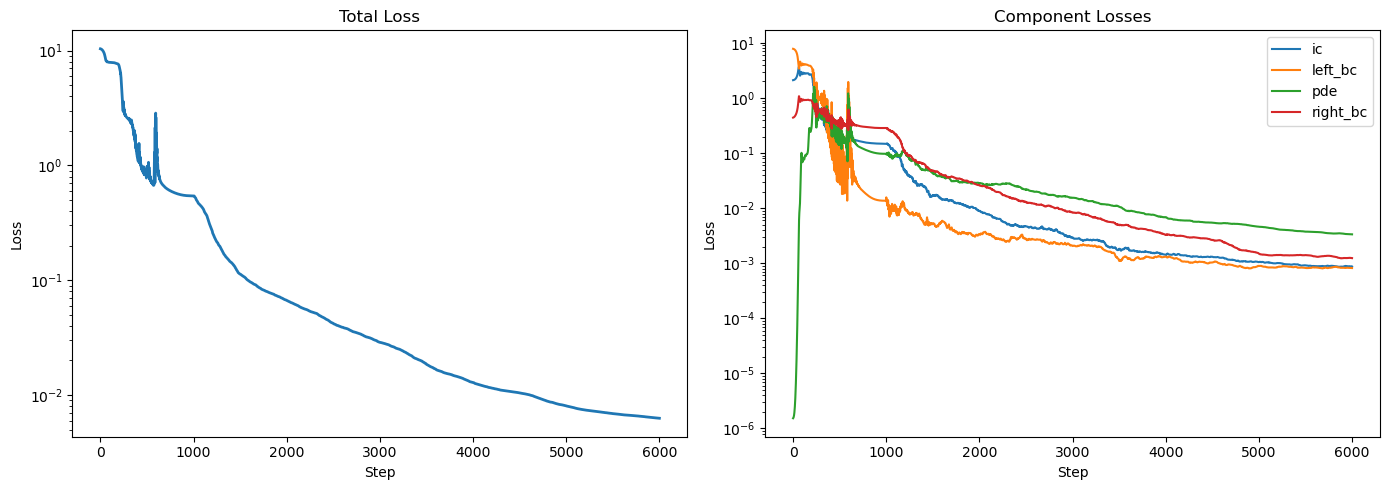

In [11]:
plot_training_history(history)

We'll check our trained solution against a numerical solver ([`dadi`](https://github.com/RyanGutenkunst/dadi)) at $t = 1$ and for various $\gamma$ values. `dadi` works in the untransformed frequency $\phi(x,t)$, so we'll need to multiply it by $x(1-x)$ to convert it to $g(x,t)$

In [12]:
import dadi
import numpy as np

TEST_GAMMA = np.linspace(-10, 10, 8)


def calc_dadi(gamma, tf=1.0, pts=300):
    xx = dadi.Numerics.default_grid(pts=pts)
    phi0 = dadi.PhiManip.phi_1D(xx, gamma=gamma)
    phif = dadi.Integration.one_pop(phi0, xx, tf, lambda t: NFUNC(t), gamma=gamma)
    return xx, phif, phi0

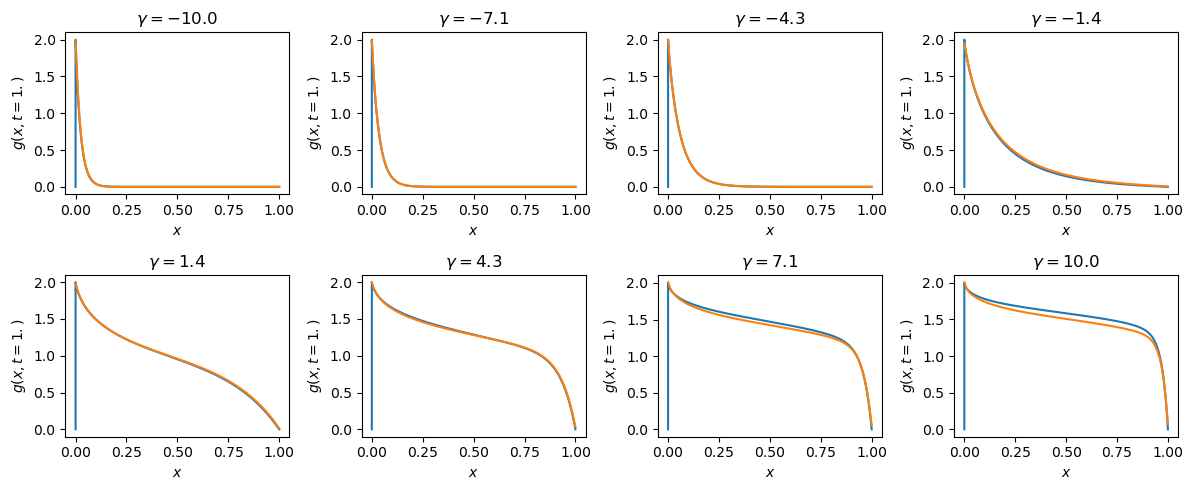

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 5))
axes = axes.flatten()
for idx, g in enumerate(TEST_GAMMA):
    x_dadi, phi_dadi, _ = calc_dadi(g)
    g_test = jax.vmap(model, in_axes=(0, None, None))(X_pde, 1.0, (g,))
    ax = axes[idx]
    ax.plot(x_dadi, phi_dadi * x_dadi * (1.0 - x_dadi))
    ax.plot(X_pde, g_test)
    ax.set_title(rf"$\gamma = {g:.1f}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$g(x, t = 1.)$")
plt.tight_layout()

After only 1k Adam and 5k L-BFGS training steps, we've achieved relatively accurate solutions across the range of $\gamma$ values we trained on. We can see in the loss history plot above that the loss was still decreasing, so if we trained for longer our solutions would continue to get better. 

## Next Steps

Now you're ready to move onto the DeepONet example, where we'll look at more complicated auxiliary inputs and batching.